In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-02-14/age_gaps.csv"
age_gaps = pd.read_csv(url)

age_gaps.columns = age_gaps.columns.str.lower()

# parse dates
date_cols = [c for c in age_gaps.columns if "birthdate" in c]
for c in date_cols:
    age_gaps[c] = pd.to_datetime(age_gaps[c], errors="coerce")

age_gaps.info()
age_gaps.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   movie_name          1155 non-null   object        
 1   release_year        1155 non-null   int64         
 2   director            1155 non-null   object        
 3   age_difference      1155 non-null   int64         
 4   couple_number       1155 non-null   int64         
 5   actor_1_name        1155 non-null   object        
 6   actor_2_name        1155 non-null   object        
 7   character_1_gender  1155 non-null   object        
 8   character_2_gender  1155 non-null   object        
 9   actor_1_birthdate   1155 non-null   datetime64[ns]
 10  actor_2_birthdate   1155 non-null   datetime64[ns]
 11  actor_1_age         1155 non-null   int64         
 12  actor_2_age         1155 non-null   int64         
dtypes: datetime64[ns](2), int64(5), object(6)
memory

,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


In [63]:
df_copy = age_gaps.copy()
df =df_copy.drop(columns=['actor_1_birthdate', 'actor_2_birthdate', 'couple_number'])

## Text Preprocessing
In this section, I will prepare the text for text mining (Bag of Words)

In [64]:
# Look for duplicates
df["movie_name"].nunique()

830

In [65]:
# Make sure duplicates are for the same movie + DIFFERENT actor pairings
# Drop columns *if* duplicates are for the same move + SAME actor pairing

df[df.duplicated("movie_name", keep=False)].sort_values("movie_name")

,movie_name,release_year,director,age_difference,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_age,actor_2_age
963,10 Things I Hate About You,1999,Gil Junger,2,Heath Ledger,Julia Stiles,man,woman,20,18
1125,10 Things I Hate About You,1999,Gil Junger,0,Joseph Gordon-Levitt,Larisa Oleynik,man,woman,18,18
464,27 Dresses,2008,Anne Fletcher,10,Edward Burns,Malin Akerman,man,woman,40,30
742,27 Dresses,2008,Anne Fletcher,5,James Marsden,Katherine Heigl,man,woman,35,30
561,A Happening of Monumental Proportions,2017,Judy Greer,8,Keanu Reeves,Jennifer Garner,man,woman,53,45
...,...,...,...,...,...,...,...,...,...,...
376,You Only Live Twice,1967,Lewis Gilbert,13,Sean Connery,Mie Hama,man,woman,37,24
619,You Only Live Twice,1967,Lewis Gilbert,8,Sean Connery,Karin Dor,man,woman,37,29
811,Zombieland: Double Tap,2019,Ruben Fleischer,5,Jesse Eisenberg,Emma Stone,man,woman,36,31
223,Zombieland: Double Tap,2019,Ruben Fleischer,18,Woody Harrelson,Rosario Dawson,man,woman,58,40


In [66]:
df.groupby("movie_name").size().sort_values(ascending=False).head(10)

,0
movie_name,
Love Actually,7
The Family Stone,6
Mona Lisa Smile,5
He's Just Not That Into You,5
A View to a Kill,5
A Star Is Born,4
Sex and the City,4
The Favourite,4
Boogie Nights,4


In [67]:
# Collapse duplicated movies to 1 entry per movie

movie_df = df.groupby("movie_name").agg({
    "age_difference": "mean", #mean age difference to keep balance
    "release_year": "first"
}).reset_index()

movie_df

,movie_name,age_difference,release_year
0,10 Things I Hate About You,1.000000,1999
1,13 Going on 30,5.000000,2004
2,15 Minutes,24.000000,2001
3,27 Dresses,7.500000,2008
4,300,4.000000,2007
...,...,...,...
825,You Only Live Twice,10.666667,1967
826,You Should Have Left,27.000000,2020
827,Zombieland,5.000000,2009
828,Zombieland: Double Tap,11.333333,2019


In [68]:
movie_df_mod = movie_df.copy()

movie_df_mod["movie_name"] = (
    movie_df_mod["movie_name"]
      .astype(str)
      .str.lower()
      .str.replace(r"[^\w\s]", "", regex=True)
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

movie_df_mod

,movie_name,age_difference,release_year
0,10 things i hate about you,1.000000,1999
1,13 going on 30,5.000000,2004
2,15 minutes,24.000000,2001
3,27 dresses,7.500000,2008
4,300,4.000000,2007
...,...,...,...
825,you only live twice,10.666667,1967
826,you should have left,27.000000,2020
827,zombieland,5.000000,2009
828,zombieland double tap,11.333333,2019


## Text Tokenization

In [69]:
!pip install nltk

In [70]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [71]:
from nltk.tokenize import word_tokenize

movie_df_mod["tokens"] = df["movie_name"].apply(word_tokenize)

In [72]:
from nltk.tokenize import word_tokenize

tokens_df = movie_df_mod.apply(
    lambda x: word_tokenize(x["movie_name"]),
    axis=1
).to_frame(name="tokens")

tokens_df.head()

,tokens
0,"[10, things, i, hate, about, you]"
1,"[13, going, on, 30]"
2,"[15, minutes]"
3,"[27, dresses]"
4,[300]


### Unigrams

In [73]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    tokenizer=word_tokenize,
    stop_words='english',
    lowercase=False #already cleaned
)

cv.fit(movie_df_mod["movie_name"])

print("Number of tokens:", len(cv.vocabulary_))


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Number of tokens: 1130


In [74]:
data_vectorized = cv.transform(movie_df_mod["movie_name"])

dtm = pd.DataFrame(
    data_vectorized.toarray(),
    columns=cv.get_feature_names_out()
)

dtm.head()

,10,12,13,15,2,27,30,300,3000,40year,...,yogi,york,young,z,zoe,zohan,zombieland,zoo,zoolander,zorro
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [75]:
movie_df_mod.columns

Index(['movie_name', 'age_difference', 'release_year', 'tokens'], dtype='object')

In [76]:
import pandas as pd

#age gap categories

movie_df_mod["age_bin"] = pd.cut(
    movie_df_mod["age_difference"],
    bins=[0,5,10,20,50],
    labels=["Small","Moderate","Large","Extreme"]
)

dtm["age_bin"] = movie_df_mod["age_bin"].values

In [77]:
word_counts_by_bin = dtm.groupby("age_bin").sum(numeric_only=True)
word_counts_by_bin.head()

/tmp/ipython-input-1369586527.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  word_counts_by_bin = dtm.groupby("age_bin").sum(numeric_only=True)


,10,12,13,15,2,27,30,300,3000,40year,...,yogi,york,young,z,zoe,zohan,zombieland,zoo,zoolander,zorro
age_bin,,,,,,,,,,,,,,,,,,,,,
Small,1,1,1,0,1,0,1,1,0,1,...,0,1,1,0,0,0,1,0,0,0
Moderate,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,1,1,0,0,1,1
Large,0,1,0,0,1,0,0,0,1,0,...,1,1,0,1,0,0,1,1,0,0
Extreme,0,0,0,1,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [78]:
top_n = 15

for b in word_counts_by_bin.index:
    top_words = word_counts_by_bin.loc[b].sort_values(ascending=False).head(top_n)
    print(f"\n=== Top {top_n} words for {b} ===")
    print(top_words)


=== Top 15 words for Small ===
love        6
man         4
walk        3
time        3
new         3
woman       3
story       3
mountain    3
moon        3
la          3
captain     2
holiday     2
artist      2
mirror      2
hidden      2
Name: Small, dtype: int64

=== Top 15 words for Moderate ===
love        7
american    4
wedding     4
man         3
girl        3
black       3
good        3
forever     2
home        2
xmen        2
wife        2
hard        2
women       2
guy         2
fiction     2
Name: Moderate, dtype: int64

=== Top 15 words for Large ===
girl        6
man         4
american    3
day         3
seven       2
avengers    2
war         2
love        2
state       2
gun         2
living      2
casino      2
proposal    2
gone        2
remember    2
Name: Large, dtype: int64

=== Top 15 words for Extreme ===
man         3
wives       2
witch       2
iii         2
gangster    2
dark        2
knock       2
love        2
big         2
murder      2
american    2
15

In [79]:
rel = word_counts_by_bin.div(word_counts_by_bin.sum(axis=1), axis=0)

top_n = 15
for b in rel.index:
    top_words = rel.loc[b].sort_values(ascending=False).head(top_n)
    print(f"\n=== Most distinctive (relative freq) for {b} ===")
    print(top_words)


=== Most distinctive (relative freq) for Small ===
love        0.013393
man         0.008929
walk        0.006696
time        0.006696
new         0.006696
woman       0.006696
story       0.006696
mountain    0.006696
moon        0.006696
la          0.006696
captain     0.004464
holiday     0.004464
artist      0.004464
mirror      0.004464
hidden      0.004464
Name: Small, dtype: float64

=== Most distinctive (relative freq) for Moderate ===
love        0.015766
american    0.009009
wedding     0.009009
man         0.006757
girl        0.006757
black       0.006757
good        0.006757
forever     0.004505
home        0.004505
xmen        0.004505
wife        0.004505
hard        0.004505
women       0.004505
guy         0.004505
fiction     0.004505
Name: Moderate, dtype: float64

=== Most distinctive (relative freq) for Large ===
girl        0.014815
man         0.009877
american    0.007407
day         0.007407
seven       0.004938
avengers    0.004938
war         0.004938
love 

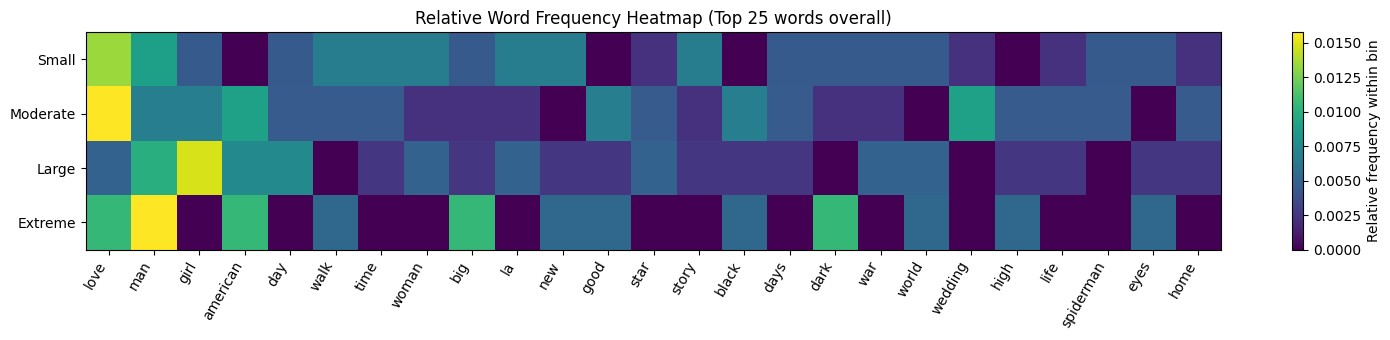

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# top n-words overall
top_n = 25
top_terms = word_counts_by_bin.sum(axis=0).sort_values(ascending=False).head(top_n).index

# relative frequency within bins
rel = word_counts_by_bin.div(word_counts_by_bin.sum(axis=1), axis=0)
rel_top = rel[top_terms].fillna(0)

# plot heatmap
plt.figure(figsize=(0.45 * top_n + 4, 3.5)) #expand sizing
plt.imshow(rel_top.values, aspect="auto")
plt.colorbar(label="Relative frequency within bin")
plt.yticks(range(rel_top.shape[0]), rel_top.index.astype(str))
plt.xticks(range(rel_top.shape[1]), rel_top.columns, rotation=60, ha="right")
plt.title(f"Relative Word Frequency Heatmap (Top {top_n} words overall)")
plt.tight_layout()
plt.show()

#### Bi-grams
repeat but with bi-grams instead of uni-grams

In [81]:
cv = CountVectorizer(
    tokenizer=word_tokenize,
    stop_words='english',
    lowercase=False,
    ngram_range=(1,2)
)

cv.fit(movie_df_mod["movie_name"])

print("Number of tokens:", len(cv.vocabulary_))

Number of tokens: 1811


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [82]:
data_vectorized = cv.transform(movie_df_mod["movie_name"])

dtm = pd.DataFrame(
    data_vectorized.toarray(),
    columns=cv.get_feature_names_out()
)

In [83]:
dtm["age_bin"] = movie_df_mod["age_bin"].values

word_counts_by_bin = dtm.groupby("age_bin").sum(numeric_only=True)

/tmp/ipython-input-1315556421.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  word_counts_by_bin = dtm.groupby("age_bin").sum(numeric_only=True)


In [84]:
top_n = 15

for b in word_counts_by_bin.index:
    top_words = word_counts_by_bin.loc[b].sort_values(ascending=False).head(top_n)
    print(f"\n=== Top {top_n} terms for {b} ===")
    print(top_words)


=== Top 15 terms for Small ===
love        6
man         4
la          3
mountain    3
moon        3
walk        3
woman       3
story       3
time        3
new         3
holiday     2
girl        2
wonder      2
friends     2
friday      2
Name: Small, dtype: int64

=== Top 15 terms for Moderate ===
love              7
wedding           4
american          4
good              3
girl              3
man               3
black             3
ghost             2
women             2
forever           2
spy               2
book              2
bridget joness    2
long              2
bridget           2
Name: Moderate, dtype: int64

=== Top 15 terms for Large ===
girl        6
man         4
american    3
day         3
world       2
woman       2
ted         2
avengers    2
star        2
street      2
society     2
state       2
smart       2
war         2
seven       2
Name: Large, dtype: int64

=== Top 15 terms for Extreme ===
man               3
love              2
knock             2
iii   

## K-Means Clustering

Attempt to see if clusters emerge based on the language used in titles

In [85]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
dtm_no_label = dtm.drop(columns=["age_bin"])

clusters = kmeans.fit_predict(dtm_no_label)

dtm["cluster"] = clusters

In [86]:
pd.crosstab(dtm["cluster"], dtm["age_bin"])

age_bin,Small,Moderate,Large,Extreme
cluster,,,,
0,240,239,230,105
1,1,0,0,0
2,2,0,0,0


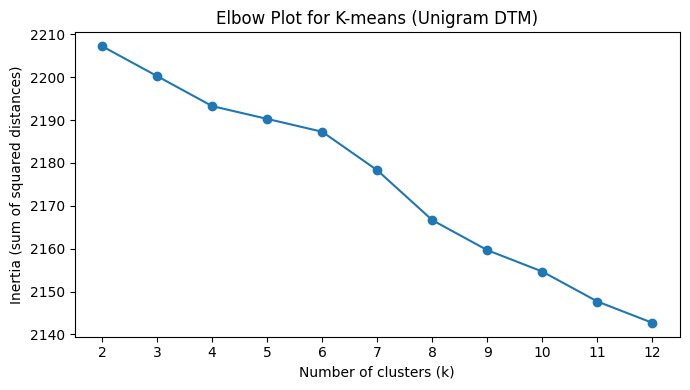

In [87]:
# see elbow
import matplotlib.pyplot as plt

k_values = range(2, 13)
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_uni)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow Plot for K-means (Unigram DTM)")
plt.tight_layout()
plt.show()